# Notebook 04 — Offline BKT Evaluation

## Goal
Measure how well BKT predicts the next response for students who were not used to estimate the model parameters.

The data are split by student rather than by row. BKT is fitted only on training students and evaluated on held-out students. The results establish **predictive validity**; they do not prove that the latent mastery probabilities are objectively true or that recommendations cause learning gains.

## 1. Load, validate, and split the data

Repeated `(user_id, skill_name, order_id)` events are removed before evaluation. Skill and student thresholds are then reapplied so that the evaluation data follow the intended preprocessing rules.

In [1]:
# Cell 1 — Load, validate, deduplicate, and split students 80/20
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = Path('../outputs/clean_data.csv')
OUTPUT_DIR = Path('../outputs')
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
required = {'user_id', 'skill_name', 'correct', 'order_id'}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
if not set(df['correct'].dropna().unique()).issubset({0, 1}):
    raise ValueError('correct must contain only 0 and 1')

rows_loaded = len(df)
event_key = ['user_id', 'skill_name', 'order_id']
duplicate_group_rows = int(df.duplicated(event_key, keep=False).sum())
df = df.drop_duplicates(event_key, keep='first').copy()
rows_after_deduplication = len(df)

# Reapply the thresholds used by preprocessing after event deduplication.
skill_counts = df['skill_name'].value_counts()
eligible_skills = skill_counts[skill_counts >= 100].index
df = df[df['skill_name'].isin(eligible_skills)].copy()
student_counts = df.groupby('user_id').size()
eligible_students = student_counts[student_counts >= 10].index
df = df[df['user_id'].isin(eligible_students)].copy()
df = df.sort_values(['user_id', 'order_id'], kind='stable').reset_index(drop=True)

# opportunity is reporting metadata; rebuild it after removing repeated events.
if 'opportunity' in df.columns:
    df['opportunity'] = df.groupby(['user_id', 'skill_name']).cumcount() + 1

all_students = df['user_id'].drop_duplicates().to_numpy()
train_students, test_students = train_test_split(
    all_students, test_size=0.20, random_state=42
)
train_df = df[df['user_id'].isin(train_students)].copy()
test_df = df[df['user_id'].isin(test_students)].copy()

assert set(train_students).isdisjoint(set(test_students))
assert len(train_df) + len(test_df) == len(df)

print(f'Rows loaded: {rows_loaded:,}')
print(f'Rows belonging to repeated event groups: {duplicate_group_rows:,}')
print(f'Rows after event deduplication: {rows_after_deduplication:,}')
print(f'Rows after thresholds: {len(df):,}')
print(f'Students: {len(all_students):,}; skills: {df["skill_name"].nunique():,}')
print(f'Train: {len(train_students):,} students, {len(train_df):,} rows')
print(f'Test:  {len(test_students):,} students, {len(test_df):,} rows')

Rows loaded: 294,418
Rows belonging to repeated event groups: 0
Rows after event deduplication: 294,418
Rows after thresholds: 294,418
Students: 3,053; skills: 92
Train: 2,442 students, 234,832 rows
Test:  611 students, 59,586 rows


## 2. Fit BKT on training students only

`num_fits=1` keeps development runs manageable. Use 3–5 random initializations for the final reported thesis run. Single-process fitting is used for predictable Windows/Jupyter behavior.

In [2]:
# Cell 2 — Fit BKT on training students only
import importlib
from pyBKT.fit import EM_fit

# Ensure a long-lived notebook kernel uses the repaired local EM implementation.
importlib.reload(EM_fit)
from pyBKT.models import Model

model = Model(seed=42, num_fits=1, parallel=False)
print('Fitting BKT on training students...')
model.fit(data=train_df, skills='.*')

fit_params = model.params()
if not np.isfinite(fit_params['value']).all():
    invalid = fit_params[~np.isfinite(fit_params['value'])]
    raise RuntimeError(
        f'BKT fitting failed: {len(invalid)} non-finite parameter values.'
    )

print(f'Fitted {fit_params.index.get_level_values("skill").nunique()} skill models.')
print('All fitted parameter values are finite.')

Fitting BKT on training students...
Fitted 92 skill models.
All fitted parameter values are finite.


## 3. Predict responses for held-out students

Predictions for a test student's first interaction use the population prior. Later one-step-ahead predictions may use that student's earlier observed test responses, matching an online knowledge-tracing setting.

In [3]:
# Cell 3 — Predict on unseen test students
train_skills = set(train_df['skill_name'].unique())
test_skills = set(test_df['skill_name'].unique())
unseen_test_skills = sorted(test_skills.difference(train_skills))
if unseen_test_skills:
    raise RuntimeError(f'Test contains skills absent from training: {unseen_test_skills}')

# pyBKT converts fitted skill names into an unescaped regex internally. Resetting
# the selector avoids dropping names that contain +, *, parentheses, and similar characters.
model.skills = '.*'
print('Predicting on held-out students...')
test_predictions = model.predict(data=test_df)

prediction_columns = ['correct_predictions', 'state_predictions']
for column in prediction_columns:
    values = test_predictions[column]
    if not np.isfinite(values).all():
        raise RuntimeError(f'{column} contains non-finite values')
    if not values.between(0, 1).all():
        raise RuntimeError(f'{column} contains values outside [0, 1]')

print('Prediction columns:', test_predictions.columns.tolist())
print(test_predictions[[
    'user_id', 'skill_name', 'correct', 'correct_predictions'
]].head(10))

Predicting on held-out students...
Prediction columns: ['user_id', 'skill_name', 'correct', 'opportunity', 'hint_count', 'attempt_count', 'order_id', 'original', 'ms_first_response', 'correct_predictions', 'state_predictions']
   user_id    skill_name  correct  correct_predictions
0       14  Circle Graph        0              0.47086
1       14    Percent Of        0              0.50670
2       14  Circle Graph        1              0.33835
3       14    Percent Of        1              0.36315
5       14    Percent Of        0              0.64893
4       14  Circle Graph        0              0.57110
7       14    Percent Of        0              0.55569
6       14  Circle Graph        0              0.44046
9       14    Percent Of        0              0.41554
8       14  Circle Graph        0              0.31462


## 4. Overall predictive performance

AUC measures ranking ability, accuracy uses a 0.5 decision threshold, and RMSE evaluates probability error. Results should be interpreted relative to the baseline below rather than against an unsupported universal cutoff.

In [4]:
# Cell 4 — Compute AUC, accuracy, and RMSE
from sklearn.metrics import (
    accuracy_score, mean_squared_error, roc_auc_score, roc_curve
)

y_true = test_predictions['correct'].astype(int)
y_prob = test_predictions['correct_predictions'].astype(float)
if y_true.nunique() != 2:
    raise RuntimeError('Overall AUC requires both correct and incorrect test responses')
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_prob))

print('=== BKT EVALUATION — HELD-OUT STUDENTS ===')
print(f'AUC-ROC:  {auc:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'RMSE:     {rmse:.4f}')

=== BKT EVALUATION — HELD-OUT STUDENTS ===
AUC-ROC:  0.7198
Accuracy: 0.7133
RMSE:     0.4396


## 5. ROC curve

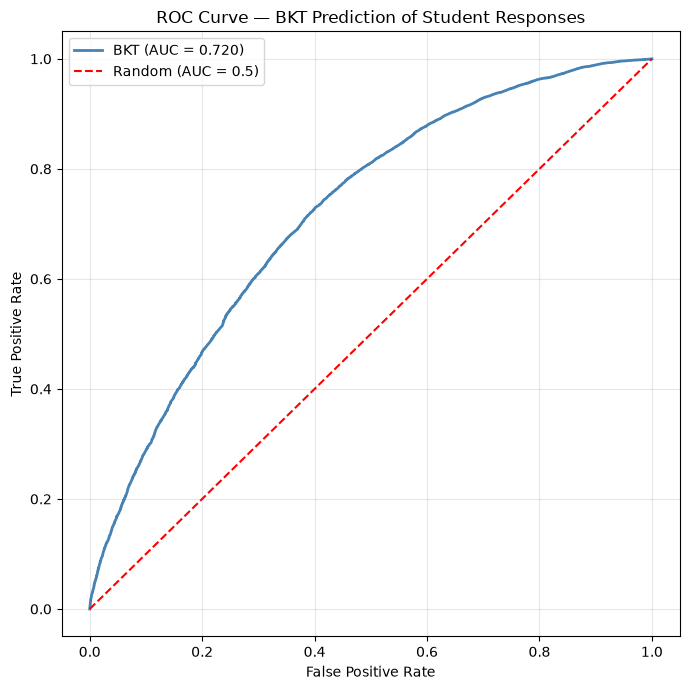

In [5]:
# Cell 5 — Plot the ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'BKT (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — BKT Prediction of Student Responses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'roc_curve.png', dpi=150)
plt.show()

## 6. Per-skill performance

Per-skill AUC is reported only when the test subset has at least 30 observations and contains both response classes. Small-sample estimates should still be interpreted cautiously.

In [6]:
# Cell 6 — Compute AUC per skill
results = []
for skill, sub in test_predictions.groupby('skill_name', sort=False):
    if len(sub) >= 30 and sub['correct'].nunique() == 2:
        results.append({
            'skill_name': skill,
            'auc': roc_auc_score(sub['correct'], sub['correct_predictions']),
            'n': len(sub),
            'correct_rate': sub['correct'].mean(),
        })

skill_results = pd.DataFrame(
    results, columns=['skill_name', 'auc', 'n', 'correct_rate']
).sort_values('auc', ascending=False, ignore_index=True)
if skill_results.empty:
    raise RuntimeError('No skill has enough test data for per-skill AUC')

macro_skill_auc = skill_results['auc'].mean()
weighted_skill_auc = np.average(skill_results['auc'], weights=skill_results['n'])
print('Top 10 best-predicted skills:')
print(skill_results.head(10))
print('\nBottom 10 worst-predicted skills:')
print(skill_results.tail(10))
print(f'\nMacro mean per-skill AUC: {macro_skill_auc:.4f}')
print(f'Weighted mean per-skill AUC: {weighted_skill_auc:.4f}')

Top 10 best-predicted skills:
                                          skill_name     auc     n  \
0                                Scientific Notation 0.80778   358   
1                                   Pattern Finding  0.80215   917   
2                                   Finding Percents 0.79771  1654   
3  Effect of Changing Dimensions of a Shape Prpor... 0.78685   190   
4                                           Percents 0.77826    33   
5                 Addition and Subtraction Fractions 0.77199  2312   
6                                       Prime Number 0.75490   156   
7                                               Mode 0.75475   410   
8         Addition and Subtraction Positive Decimals 0.75400  1117   
9                                           Rounding 0.74845   228   

   correct_rate  
0       0.73464  
1       0.62377  
2       0.51935  
3       0.56316  
4       0.30303  
5       0.63754  
6       0.77564  
7       0.86585  
8       0.56670  
9       0.70614  



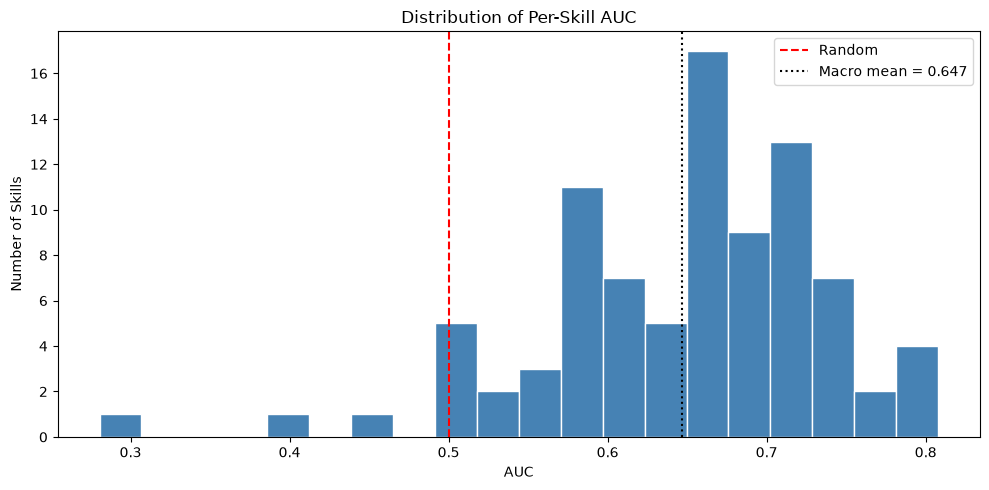

In [7]:
# Cell 7 — Visualize the per-skill AUC distribution
plt.figure(figsize=(10, 5))
plt.hist(skill_results['auc'], bins=20,
         color='steelblue', edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', label='Random')
plt.axvline(x=macro_skill_auc, color='black', linestyle=':',
            label=f'Macro mean = {macro_skill_auc:.3f}')
plt.title('Distribution of Per-Skill AUC')
plt.xlabel('AUC')
plt.ylabel('Number of Skills')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'per_skill_auc.png', dpi=150)
plt.show()

## 7. Skill-average baseline

The baseline predicts each test response using that skill's average correctness among training students. This tests whether student-state tracking adds predictive value beyond population-level skill difficulty.

In [8]:
# Cell 8 — Compare BKT with a skill-average baseline
skill_average = train_df.groupby('skill_name')['correct'].mean()
test_predictions['baseline_pred'] = (
    test_predictions['skill_name'].map(skill_average)
    .fillna(train_df['correct'].mean())
)

baseline_prob = test_predictions['baseline_pred']
baseline_predicted_class = (baseline_prob >= 0.5).astype(int)
baseline_auc = roc_auc_score(y_true, baseline_prob)
baseline_accuracy = accuracy_score(y_true, baseline_predicted_class)
baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_prob))

print('=== BKT VS SKILL-AVERAGE BASELINE ===')
print(f'{"Model":<24}{"AUC":>10}{"Accuracy":>12}{"RMSE":>10}')
print('-' * 56)
print(f'{"Skill-average baseline":<24}{baseline_auc:>10.4f}'
      f'{baseline_accuracy:>12.4f}{baseline_rmse:>10.4f}')
print(f'{"BKT":<24}{auc:>10.4f}{accuracy:>12.4f}{rmse:>10.4f}')

=== BKT VS SKILL-AVERAGE BASELINE ===
Model                          AUC    Accuracy      RMSE
--------------------------------------------------------
Skill-average baseline      0.6206      0.6588    0.4658
BKT                         0.7198      0.7133    0.4396


## 8. Save reproducible evaluation outputs

In [9]:
# Cell 9 — Save summary, per-skill metrics, and held-out predictions
summary = pd.DataFrame([{
    'model': 'BKT',
    'auc': auc,
    'accuracy': accuracy,
    'rmse': rmse,
    'baseline_auc': baseline_auc,
    'baseline_accuracy': baseline_accuracy,
    'baseline_rmse': baseline_rmse,
    'macro_skill_auc': macro_skill_auc,
    'weighted_skill_auc': weighted_skill_auc,
    'n_train_students': len(train_students),
    'n_test_students': len(test_students),
    'n_train_rows': len(train_df),
    'n_test_rows': len(test_df),
    'n_evaluated_skills': len(skill_results),
    'seed': 42,
    'num_fits': model.num_fits,
}])

summary.to_csv(OUTPUT_DIR / 'evaluation_results.csv', index=False)
skill_results.to_csv(OUTPUT_DIR / 'per_skill_auc.csv', index=False)
test_predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

print('Saved:')
print(' -', OUTPUT_DIR / 'evaluation_results.csv')
print(' -', OUTPUT_DIR / 'per_skill_auc.csv')
print(' -', OUTPUT_DIR / 'test_predictions.csv')
print('\nSummary:')
print(summary.T)

Saved:
 - ..\outputs\evaluation_results.csv
 - ..\outputs\per_skill_auc.csv
 - ..\outputs\test_predictions.csv

Summary:
                         0
model                  BKT
auc                0.71977
accuracy           0.71329
rmse               0.43965
baseline_auc       0.62061
baseline_accuracy  0.65880
baseline_rmse      0.46577
macro_skill_auc    0.64667
weighted_skill_auc 0.67843
n_train_students      2442
n_test_students        611
n_train_rows        234832
n_test_rows          59586
n_evaluated_skills      88
seed                    42
num_fits                 1


## Interpretation and thesis limitation

A held-out advantage over the skill-average baseline supports the claim that BKT's evolving student state carries predictive information beyond aggregate skill difficulty. If BKT does not outperform the baseline, that is still a valid result and should be reported directly.

This offline evaluation cannot establish causal learning gains from a personalized path. It evaluates response prediction and recommendation targeting only. For final thesis estimates, rerun with 3–5 random initializations and consider repeated student-level splits or grouped cross-validation to quantify split uncertainty.